# 网格越来越细，能把错误的支座修好吗？

先猜：把简支梁误画成两端固支，再加密网格，答案会回到简支梁吗？

本页HTML展示已运行的Python结果，不会在浏览器里重新执行Python。下载.ipynb，在Jupyter打开，改参数后选择“重新启动内核并运行全部”。依赖：Python 3、numpy、matplotlib、ipykernel。

## 今天只做一根均布荷载梁
Euler–Bernoulli梁单元，每个节点两个自由度：向下位移w和转角dw/dx。线弹性、小变形、等截面；不含剪切变形和局部应力。对应C11U03、C11U05、C11U07的进阶计算；原C11U03/07核心演示是函数插值，这里才组装梁有限元。

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.sans-serif":["Microsoft YaHei","SimHei","DejaVu Sans"],
                     "axes.unicode_minus":False, "figure.dpi":120})
print("Python", sys.version.split()[0], "；NumPy", np.__version__)

Python 3.13.5 ；NumPy 2.2.6


## 固定材料和荷载，再选择网格

In [2]:
#| label: parameters-fem
L=20.0 # m
E=34e9 # Pa
I=.1 # m⁴
q=20e3 # N/m，向下为正
n=4 # 单元数
assert min(L,E,I,q)>0 and isinstance(n,int) and n>=2

## 先准备独立的答案
简支梁：$w(x)=qx(L^3-2Lx^2+x^3)/(24EI)$，跨中$5qL^4/(384EI)$。
两端固支梁：$w(x)=qx^2(L-x)^2/(24EI)$，跨中$qL^4/(384EI)$。
$$K_e=\frac{EI}{\ell^3}\begin{bmatrix}12&6\ell&-12&6\ell\\6\ell&4\ell^2&-6\ell&2\ell^2\\-12&-6\ell&12&-6\ell\\6\ell&2\ell^2&-6\ell&4\ell^2\end{bmatrix},\quad
f_e=q[\ell/2,\ell^2/12,\ell/2,-\ell^2/12]^T.$$
f中的第1、3项是力N，第2、4项是广义节点力矩N·m，不能把四项都当力相加。

In [3]:
def solve_beam(n,support="simple"):
    length=L/n
    ke=E*I/length**3*np.array([[12,6*length,-12,6*length],
       [6*length,4*length**2,-6*length,2*length**2],
       [-12,-6*length,12,-6*length],
       [6*length,2*length**2,-6*length,4*length**2]],float)
    fe=q*np.array([length/2,length**2/12,length/2,-length**2/12])
    K=np.zeros((2*(n+1),2*(n+1)));F=np.zeros(2*(n+1))
    for j in range(n):
        dofs=np.arange(2*j,2*j+4)
        K[np.ix_(dofs,dofs)]+=ke;F[dofs]+=fe
    fixed=[0,2*n] if support=="simple" else [0,1,2*n,2*n+1]
    free=np.setdiff1d(np.arange(len(F)),fixed)
    u=np.zeros_like(F)
    u[free]=np.linalg.solve(K[np.ix_(free,free)],F[free])
    return u,K@u-F

def displacement(x,u,n):
    ell=L/n
    j=min(n-1,int(x/ell));s=(x-j*ell)/ell
    H=np.array([1-3*s*s+2*s**3,ell*(s-2*s*s+s**3),
                3*s*s-2*s**3,ell*(-s*s+s**3)])
    return H@u[2*j:2*j+4]

def exact(x,support="simple"):
    return q*x*(L**3-2*L*x*x+x**3)/(24*E*I) if support=="simple" else q*x*x*(L-x)**2/(24*E*I)

u,reactions=solve_beam(n)
xnodes=np.linspace(0,L,n+1)
print("节点位移/mm：",np.round(u[::2]*1000,6))
print("两端竖向反力/N（向下为正）：",np.round(reactions[[0,2*n]],4))
print("两端广义力矩/N·m：",np.round(reactions[[1,2*n+1]],4))
assert np.isclose(reactions[::2].sum()+q*L,0,atol=1e-5)
assert np.isclose(reactions[::2]@xnodes+reactions[1::2].sum()+q*L*L/2,0,atol=1e-3)

节点位移/mm： [ 0.        8.731618 12.254902  8.731618  0.      ]
两端竖向反力/N（向下为正）： [-200000. -200000.]
两端广义力矩/N·m： [ 0. -0.]


## 节点算得准，单元中间也一样准吗？
均布荷载下，这个等截面梁的节点位移可能非常精确；但单元内用三次函数插值，解析曲线是四次函数。看每个单元中点的误差，才能看到这次网格加密改变了什么。

In [4]:
rows=[]
for cells in [2,4,8,16]:
    displ,_=solve_beam(cells)
    mids=(np.arange(cells)+.5)*L/cells
    midpoint_error=max(abs(displacement(x,displ,cells)-exact(x)) for x in mids)
    node_error=max(abs(displ[2*j]-exact(j*L/cells)) for j in range(cells+1))
    rows.append((cells,node_error*1000,midpoint_error*1000))
print("单元数 | 最大节点误差/mm | 最大单元中点误差/mm")
for row in rows:print(f"{row[0]:5d} | {row[1]:16.9g} | {row[2]:20.9g}")
assert all(rows[i+1][2]<rows[i][2] for i in range(len(rows)-1))

单元数 | 最大节点误差/mm | 最大单元中点误差/mm
    2 |                0 |          0.153186275
    4 |   2.08166817e-14 |        0.00957414216
    8 |   6.07153217e-14 |       0.000598383885
   16 |   2.22911967e-12 |        3.7398995e-05


## 让边界也接受检查
两种模型分别向自己的解析解收敛。网格加密不能把“固支”改成“简支”。

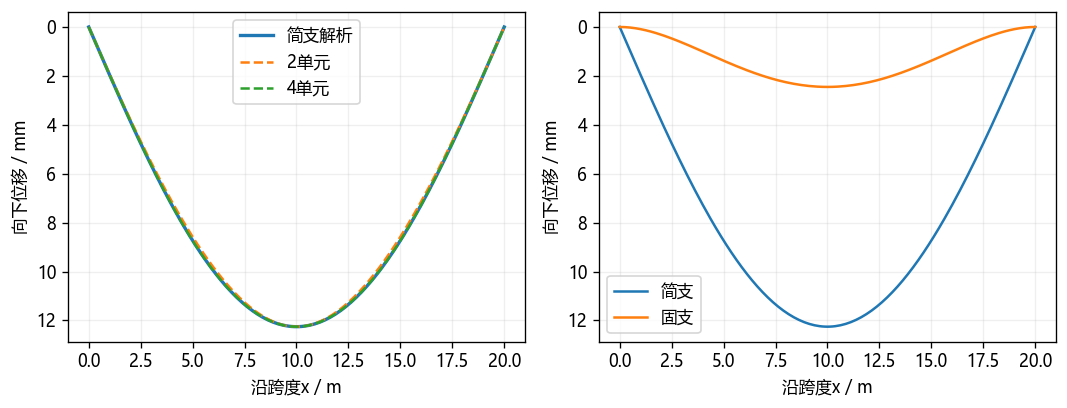

In [5]:
#| label: fig-fem
xs=np.linspace(0,L,161)
fig,axes=plt.subplots(1,2,figsize=(9,3.5))
axes[0].plot(xs,[1000*exact(x) for x in xs],label="简支解析",lw=2)
for cells in [2,4]:
    uu,_=solve_beam(cells)
    axes[0].plot(xs,[1000*displacement(x,uu,cells) for x in xs],label=f"{cells}单元",ls="--")
axes[0].set(xlabel="沿跨度x / m",ylabel="向下位移 / mm");axes[0].legend()
for support,label in [("simple","简支"),("fixed","固支")]:
    uu,_=solve_beam(8,support)
    axes[1].plot(xs,[1000*displacement(x,uu,8) for x in xs],label=label)
axes[1].set(xlabel="沿跨度x / m",ylabel="向下位移 / mm");axes[1].legend()
for ax in axes:
    ax.grid(alpha=.2)
    ax.invert_yaxis()  # 正位移向下，与本例挠曲方向保持一致。
fig.tight_layout();plt.show()

In [6]:
#| label: checks-fem
simple,_=solve_beam(8,"simple")
fixed,rf=solve_beam(8,"fixed")
ws=displacement(L/2,simple,8)
wf=displacement(L/2,fixed,8)
assert np.isclose(ws,5*q*L**4/(384*E*I),rtol=1e-8)
assert np.isclose(wf,q*L**4/(384*E*I),rtol=1e-8)
assert np.isclose(ws/wf,5)
assert np.isclose(abs(rf[1]),q*L*L/12,rtol=1e-8)
assert np.isclose(abs(rf[-1]),q*L*L/12,rtol=1e-8)
print(f"简支跨中 {ws*1000:.6f} mm；固支跨中 {wf*1000:.6f} mm；比值 {ws/wf:.3f}")
print("自检通过：力、力矩、位移解析解及固端力矩。")

简支跨中 12.254902 mm；固支跨中 2.450980 mm；比值 5.000
自检通过：力、力矩、位移解析解及固端力矩。


## 这次检验说明了什么？
默认参数下，简支跨中12.254902 mm、固支2.450980 mm，相差5倍。改变参数后以本次输出为准。

1. 只有节点误差很小，能否推出局部应力已可靠？
2. 若漏了一半荷载，求解器的内部平衡是否还能成立？
3. 把这根梁用于真实桥面轮载前，还缺哪些横向、连接和荷载信息？

本例只验证指定线性梁实现及边界；不能外推为整桥、非线性或规范设计已验收。